In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def power_method(cov: np.array, max_iter: int = 50) -> tuple[float, np.array]:
    if max_iter <= 0: raise ValueError("Invalid max_iter value")
    if cov.ndim != 2: raise ValueError("2-dimensional matrices allowed only")
    if cov.shape[0] != cov.shape[1]: raise ValueError("Square matrices allowed only")

    n = cov.shape[0]
    eigenvec = np.random.uniform(-1, 1, n)
    eigenvec /= np.linalg.norm(eigenvec)

    for _ in range(max_iter):
        eigenvec = cov @ eigenvec
        eigenvec /= np.linalg.norm(eigenvec)
    
    lam = (eigenvec.T @ cov @ eigenvec) / (eigenvec.T @ eigenvec)

    return (lam, eigenvec)

In [ ]:
def svd_via_power_method(X: np.array, max_iter: int = 50, enable_below_zero_sigma_warning: bool = True) -> tuple[np.array, np.array, np.array]:

    if max_iter <= 0: raise ValueError("Invalid max_iter value")
    if X.ndim != 2: raise ValueError("2-dimensional matrices allowed only")

    cov = X.T @ X

    U = []
    sigmas = []
    V = []

    rank = np.linalg.matrix_rank(X)

    for k in range(rank):
        lam, v = power_method(cov, max_iter)
        v = v.reshape(X.shape[1], 1)

        if lam < 0:
            if enable_below_zero_sigma_warning:
                print(f'Below zero singular value detected at iteration {k}: {lam:.3e}')
            sigma = np.sqrt(-lam)
        else:
            sigma = np.sqrt(lam)
        sigmas.append(sigma)
        V.append(v.T)
        U.append(X@v/sigma)


        cov = cov - (v @ v.T) * lam
    return np.concatenate(U, axis=1), np.array(sigmas), np.concatenate(V, axis=0)

In [ ]:
def trunc_recon(U, S, Vt, r = 300) -> np.array:
    r = min([r, U.shape[1], S.shape[0], Vt.shape[0]])
    return U[:, :r] @ np.diag(S)[:r, :r] @ Vt[:r, :]

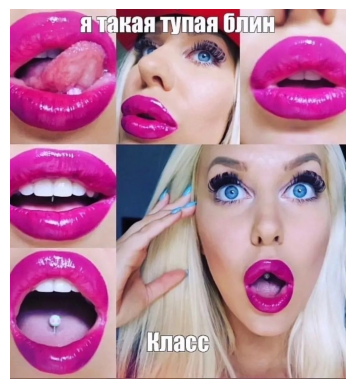

In [10]:
image = cv2.imread("./klass.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()

In [13]:
image_float = image.astype(np.float64)

R = image_float[:, :, 0]
G = image_float[:, :, 1]
B = image_float[:, :, 2]

In [21]:
svd_res = {}
iter_nums = [10, 50, 100]
r_vals = [5, 10, 20, 50]

C:\Users\user\AppData\Local\Temp\ipykernel_27176\860346256.py:9: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='red')


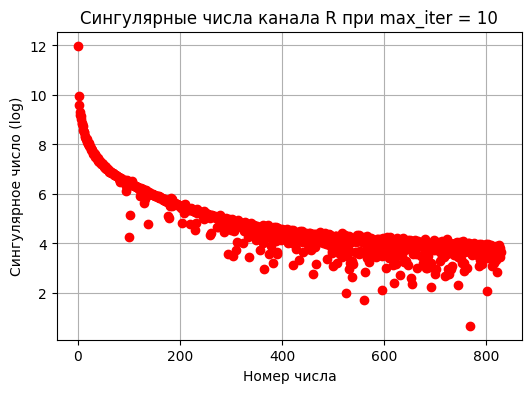

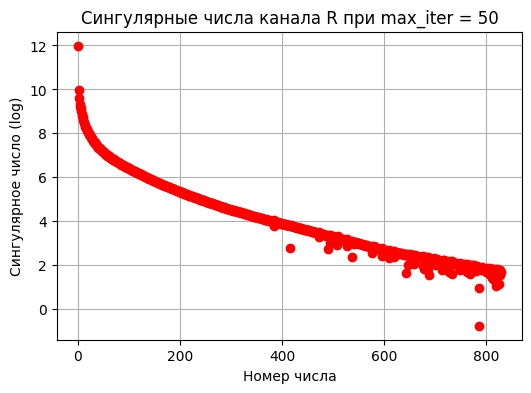

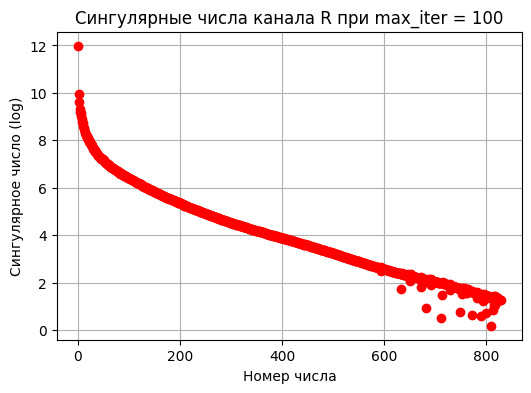

In [ ]:
svd_res['R'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(R, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(R - recon, ord='fro')
    svd_res['R'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='red')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала R при max_iter = {n}')
    ax.grid()
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_27176\171130191.py:9: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='green')


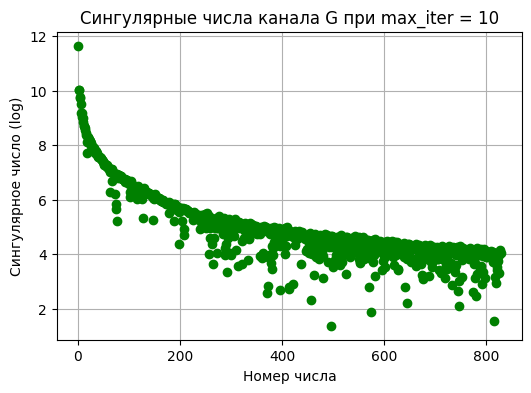

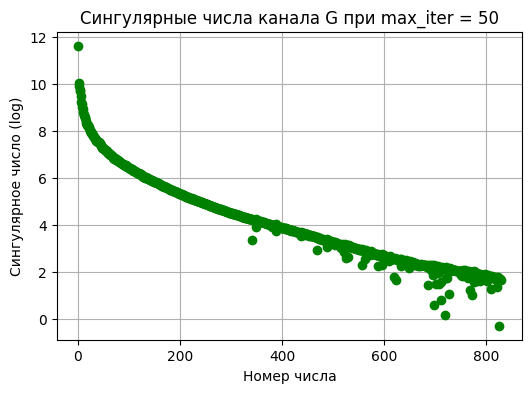

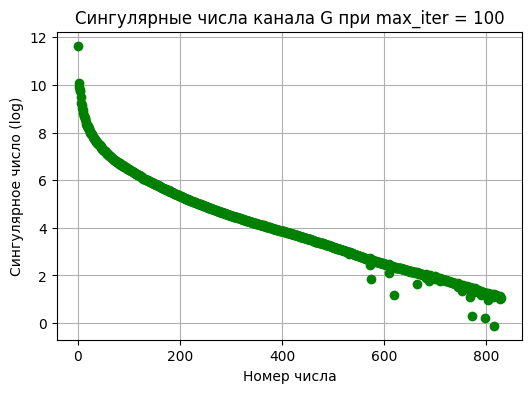

In [18]:
svd_res['G'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(G, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(G - recon, ord='fro')
    svd_res['G'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='green')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала G при max_iter = {n}')
    ax.grid()
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_27176\645496642.py:9: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='blue')


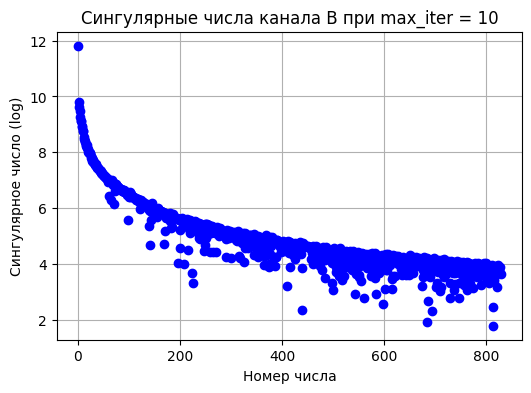

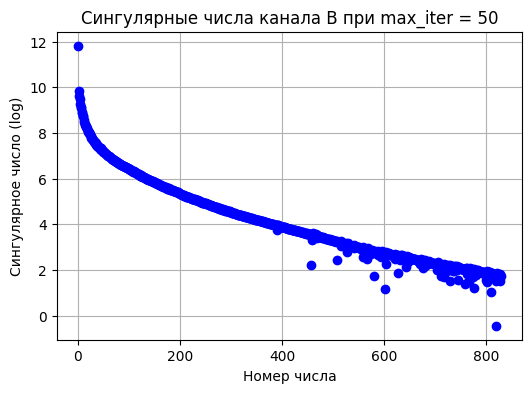

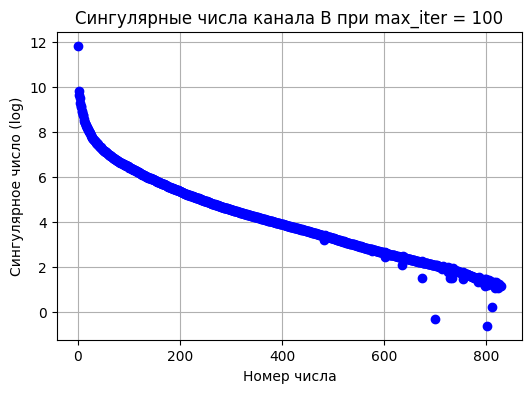

In [19]:
svd_res['B'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(B, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(B - recon, ord='fro')
    svd_res['B'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='blue')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала B при max_iter = {n}')
    ax.grid()
    plt.show()

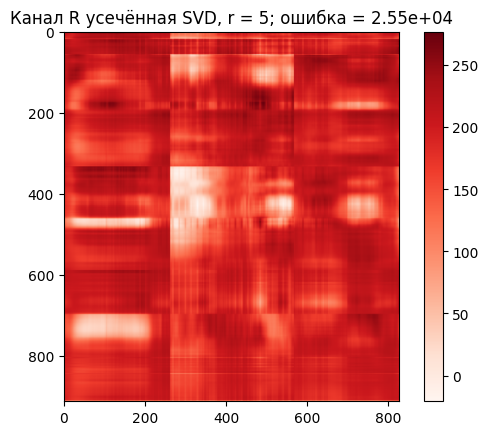

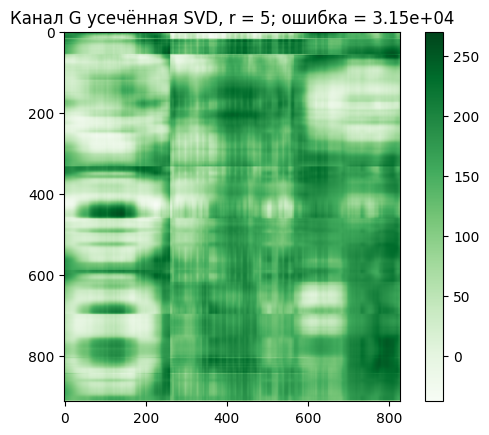

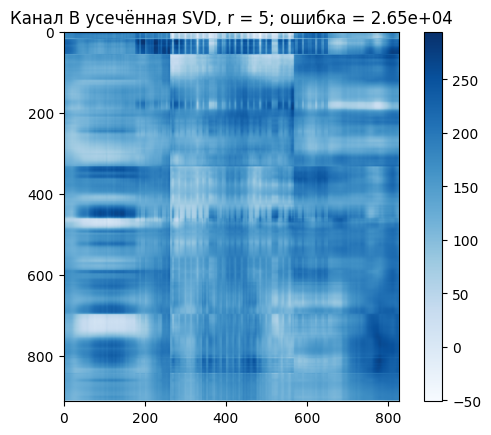

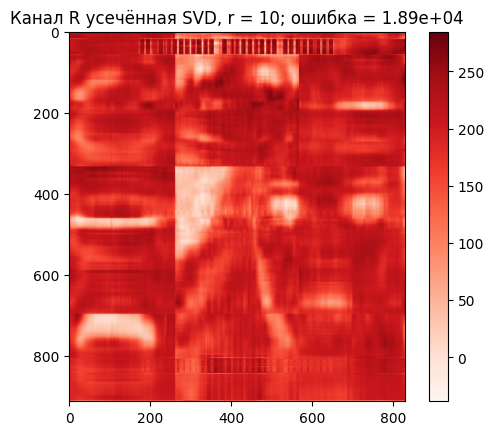

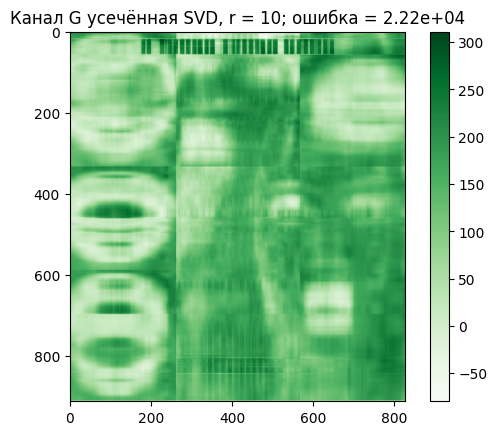

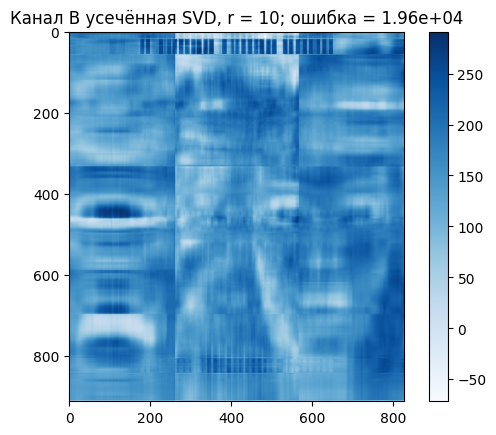

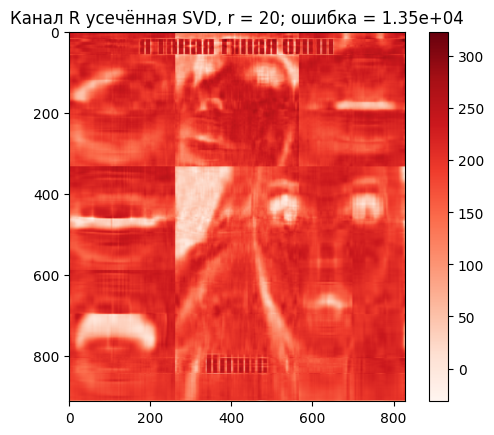

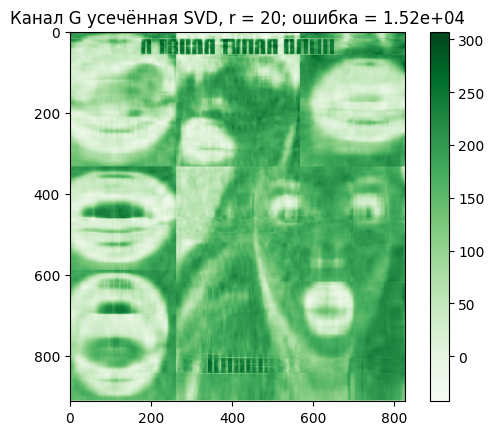

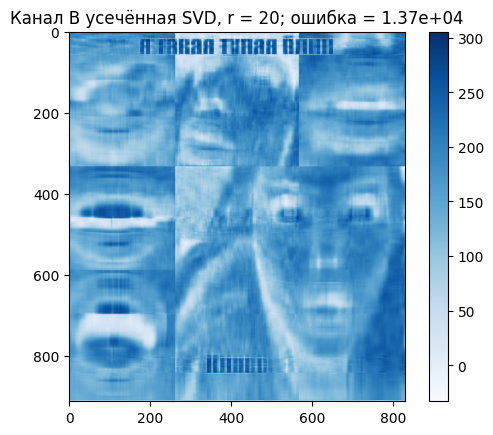

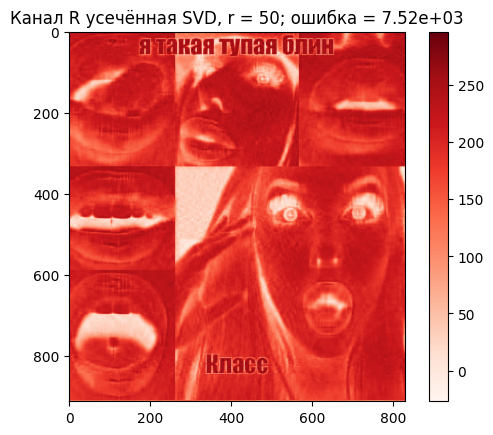

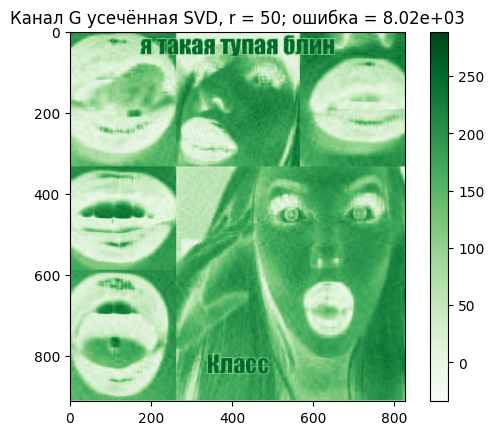

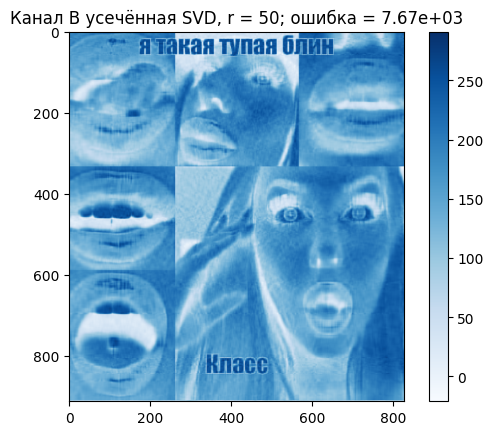

In [ ]:
UR, SR, VtR = svd_via_power_method(R, enable_below_zero_sigma_warning=False)
err_fullR = np.linalg.norm(trunc_recon(UR, SR, VtR, r=UR.shape[1]) - R, ord='fro')

UG, SG, VtG = svd_via_power_method(G, enable_below_zero_sigma_warning=False)
err_fullG = np.linalg.norm(trunc_recon(UG, SG, VtG, r=UG.shape[1]) - G, ord='fro')

UB, SB, VtB = svd_via_power_method(B, enable_below_zero_sigma_warning=False)
err_fullB = np.linalg.norm(trunc_recon(UB, SB, VtB, r=UB.shape[1]) - B, ord='fro')

for r in r_vals:
    recon_r = trunc_recon(UR, SR, VtR, r)
    err = np.linalg.norm(recon_r - R, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Reds')
    plt.title(f"Канал R приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()

    recon_r = trunc_recon(UG, SG, VtG, r)
    err = np.linalg.norm(recon_r - G, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Greens')
    plt.title(f"Канал G приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()


    recon_r = trunc_recon(UB, SB, VtB, r)
    err = np.linalg.norm(recon_r - B, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Blues')
    plt.title(f"Канал B приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()


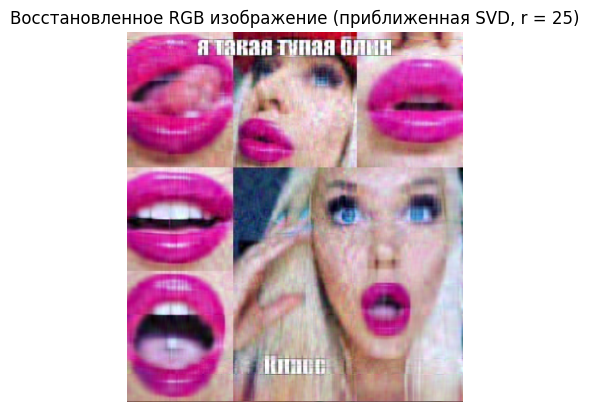

In [28]:
r_fin = 25

recon_R_fin = trunc_recon(UR, SR, VtR, r_fin)
recon_G_fin = trunc_recon(UG, SG, VtG, r_fin)
recon_B_fin = trunc_recon(UB, SB, VtB, r_fin)

recon_im = np.dstack((recon_R_fin, recon_G_fin, recon_B_fin))
recon_im = np.clip(recon_im, 0, 255).astype(np.uint8)

plt.figure()
plt.imshow(recon_im)
plt.title(f"Восстановленное RGB изображение (приближенная SVD, r = {r_fin})")
plt.axis("off")
plt.show()